Martin Ardila.


Simple relation between r (position) and p (radial momentum) in phase space (which is the space of

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt




In [2]:
#Constants
G = 6.67430e-11  #newtons constant
M = 5.972e24     #earth
m0 = 1000        #initial rocket mass(kg)
thrust = 1000    #YOU SHOULD DEFINE A THRUST FOR THE ROCKET
burn_time = 50   #Time of combustion
mass_loss_rate = 2  #parameter of lossing mass



In [3]:
#well... we are working with variable mass
def m(t):
    return max(m0 - mass_loss_rate * t, 100)  # minimum mass = 100 kg


In [4]:
#from hamiltonian functional
def hamiltonian_rhs(t, y):
    r, pr = y
    m_t = m(t)

    #canonical eq of hamilton
    drdt = pr / m_t
    dpdt = -(-G*M*m_t / r**2) + (thrust if t < burn_time else 0)

    return [drdt, dpdt]



In [5]:
#im gonna suppose some initial conditions
r0 = 6.7e6
v0 = 0
pr0 = m0 * v0
y0 = [r0, pr0]

t_span = (0, 500)
t_eval = np.linspace(*t_span, 1000)


In [6]:
sol = solve_ivp(hamiltonian_rhs, t_span, y0, t_eval=t_eval)


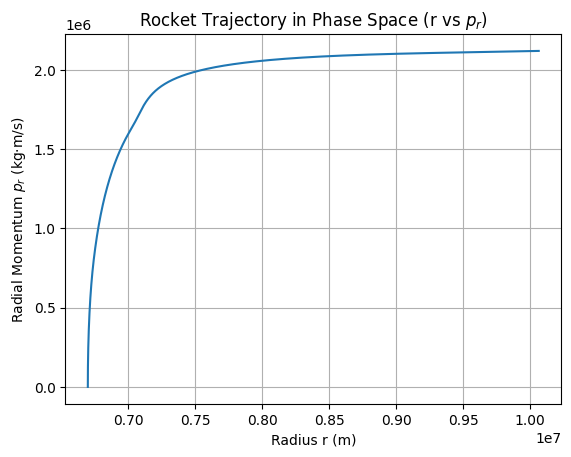

In [7]:
plt.plot(sol.y[0], sol.y[1])
plt.xlabel("Radius r (m)")
plt.ylabel("Radial Momentum $p_r$ (kg·m/s)")
plt.title("Rocket Trajectory in Phase Space (r vs $p_r$)")
plt.grid()
plt.show()